# IEMOCAP Benchmark: Proposed Cascade vs Three Competitors

**Задача:** сравнить предложенную каскадную мультимодальную архитектуру с тремя конкурентами на IEMOCAP.

## Предложенная модель (cascade)
- **Audio gate:** Log-Mel + `MelCNN` — бинарная классификация *neutral vs non-neutral* (предобучена на RAVDESS+CREMA-D, `0=neutral, 1=non_neutral`).
- **Video branch:** MediaPipe face detection → EmotiEffNet (`enet_b0_8_best_vgaf`, 1280-dim) → `BiLSTMClassifier` → 6 эмоций.
- **Fusion:** если audio-gate = neutral → итог = neutral; иначе — argmax видео-ветки.

## Конкуренты (упрощённые реализации)
1. **SCME + GF** — Sparse Cross-Modal Encoder + Gated Fusion *(2024)*. Упрощение: transformer + cross-attention между wav2vec2 и EmotiEffNet, затем gated fusion.
2. **MM-NodeFormer** — Interspeech 2024. Упрощение: два потока transformer-энкодеров + cross-modal attention на нескольких слоях + mean-pool + classifier.
3. **ResNet18 + GRU** — baseline (arXiv 2023). ResNet18 признаки per-frame + GRU.

## Датасет
IEMOCAP full release. 6 классов: `neutral, happy, sad, angry, excited, frustrated`.

**Спикер-независимый трёх-частный сплит:**
- **Session 1–3 → train**
- **Session 4 → val** (для early stopping)
- **Session 5 → test**

**Кто говорит в кадре** определяется по стерео-аудио. `dialog/wav/{dialog}.wav` записан с двух близкозаписанных мик-петличек (по одной на актёра); каналы L и R соответствуют двум актёрам. Для каждой реплики считаем RMS в окне `[start..end]` по обоим каналам — у говорящего его мик многократно громче. Per-session калибруется отображение `audio_channel ↔ video_side` (mouth-motion на ~50 длинных репликах с чётким доминированием одного канала, majority vote). Дальше для всех реплик lookup O(1).

RAVDESS emotions (для маппинга предобученной видео-головы): 0 = neutral, 1 = calm, 2 = happy, 3 = sad, 4 = angry, 5 = fearful, 6 = disgust, 7 = surprised. IEMOCAP-маппинг: `[0,0,1,2,3,5,5,4]`.

## Метрики
Accuracy, Weighted F1, inference time (мс/сэмпл), размер модели (MB).


## 1. Установка зависимостей и конфиг

In [26]:
import os, json, time, gc, warnings, pickle, math, re
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T

from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available()
                      else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Device:', device)

# --- пути (используем raw IEMOCAP_full_release напрямую, без iemocap_processed/)
IEMOCAP_ROOT      = '../datasets/IEMOCAP_full_release'
# v3: side speaker'а теперь определяется чисто визуально (mouth-motion с
# вычитанием базлайна по верхней части лица), без стерео-RMS / калибровки.
# Кеш v2 невалиден.
CACHE_DIR         = Path('../datasets/iemocap_features_cache_v3')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

AUDIO_CKPT_DIR    = '../trained_models/audio_neutral_3_augmentation'
VIDEO_CKPT_DIR    = '../trained_models/video_emotion_3_augmentation'
CKPT_OUT_DIR      = Path('../trained_models/iemocap_benchmark')
CKPT_OUT_DIR.mkdir(parents=True, exist_ok=True)

FACE_DETECTOR_PATH = '../raw_models/blaze_face_short_range.tflite'

# --- параметры
SR        = 16_000
N_MELS    = 64
MAX_LEN   = 128       # mel-фреймов
HOP       = 512
N_FRAMES  = 16        # видео-кадров на реплику
IMG_SIZE  = 224
FEAT_EFF  = 1280      # EmotiEffNet
FEAT_RES  = 512       # ResNet18
FEAT_W2V  = 768       # wav2vec2-base

# 6 классов IEMOCAP. Класса 'calm' в IEMOCAP нет — он есть только в RAVDESS.
LABELS_6 = ['neutral', 'happy', 'sad', 'angry', 'excited', 'frustrated']
RAW2IDX  = {'neu': 0, 'hap': 1, 'sad': 2, 'ang': 3, 'exc': 4, 'fru': 5}
N_CLS    = len(LABELS_6)

# --- источник истины для семантики MelCNN-гейта.
# В audio_neutral_check_augmentation.ipynb метка кодируется так:
#   RAVDESS:  labels.append(0 if emotion <= 2 else 1)   # neutral|calm → 0
#   CREMA-D:  labels.append(0 if parts[2] == "NEU" else 1)
# Поэтому 0 = neutral, 1 = non_neutral. Этот id используется в каскаде.
NEUTRAL_CLASS_ID = 0

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

def size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024**2


Device: mps


## 2. Загрузка метаданных IEMOCAP

Парсим `EmoEvaluation/*.txt` напрямую из `IEMOCAP_full_release/Session{1..5}/dialog/EmoEvaluation/` — без промежуточного `iemocap_processed/`. Из каждой строки берём `[start - end] utterance_id emotion`. Отфильтровываем по 6 эмоциональным классам (`neu, hap, sad, ang, exc, fru`); `xxx`, `oth`, `fea`, `sur`, `dis` отбрасываем. Сплит спикер-независимый: Session 1–4 → train, Session 5 → test.

In [27]:
# --- парсим EmoEvaluation/*.txt напрямую из IEMOCAP_full_release
EMO_LINE_RE = re.compile(r'^\[\s*([\d.]+)\s*-\s*([\d.]+)\s*\]\s+(\S+)\s+(\w+)\s+\[')

def parse_emoeval(eval_path, session):
    rows = []
    with open(eval_path, encoding='utf-8', errors='ignore') as f:
        for line in f:
            m = EMO_LINE_RE.match(line)
            if not m:
                continue
            start, end, utt_id, emo = m.groups()
            dialog = utt_id.rsplit('_', 1)[0]   # 'Ses01F_impro01_F000' -> 'Ses01F_impro01'
            rows.append({
                'session':      session,
                'dialog':       dialog,
                'utterance_id': utt_id,
                'start':        float(start),
                'end':          float(end),
                'emotion_raw':  emo,
            })
    return rows

records = []
for s in range(1, 6):
    sess = f'Session{s}'
    eval_dir = Path(IEMOCAP_ROOT) / sess / 'dialog' / 'EmoEvaluation'
    for txt in sorted(eval_dir.glob('*.txt')):
        if txt.name.startswith('.'):
            continue
        records.extend(parse_emoeval(txt, sess))

meta = pd.DataFrame.from_records(records)
print(f'Сырых реплик из EmoEvaluation: {len(meta)}')
print('Все категории до фильтрации:')
print(meta['emotion_raw'].value_counts().to_dict())

def audio_path(row):
    return os.path.join(IEMOCAP_ROOT, row['session'], 'sentences', 'wav',
                        row['dialog'], f"{row['utterance_id']}.wav")

def avi_path(row):
    return os.path.join(IEMOCAP_ROOT, row['session'], 'dialog', 'avi', 'DivX',
                        f"{row['dialog']}.avi")

meta['audio_path'] = meta.apply(audio_path, axis=1)
meta['avi_path']   = meta.apply(avi_path, axis=1)

# --- фильтрация по 6 классам (включая frustrated)
meta = meta[meta['emotion_raw'].isin(RAW2IDX)].reset_index(drop=True)
meta['label6'] = meta['emotion_raw'].map(RAW2IDX)

# Спикер-независимый трёх-частный сплит:
#   Session 1–3 → train, Session 4 → val (для early stopping), Session 5 → test.
def assign_split(sess):
    if sess == 'Session5': return 'test'
    if sess == 'Session4': return 'val'
    return 'train'
meta['split'] = meta['session'].map(assign_split)

print(f'\nПосле фильтрации по 6 классам: {len(meta)} | '
      f'train: {(meta.split == "train").sum()} | '
      f'val: {(meta.split == "val").sum()} | '
      f'test: {(meta.split == "test").sum()}')
print('\nРаспределение по классам:')
print(meta.groupby(['split', 'emotion_raw']).size().unstack(fill_value=0))


Сырых реплик из EmoEvaluation: 10039
Все категории до фильтрации:
{'xxx': 2507, 'fru': 1849, 'neu': 1708, 'ang': 1103, 'sad': 1084, 'exc': 1041, 'hap': 595, 'sur': 107, 'fea': 40, 'oth': 3, 'dis': 2}

После фильтрации по 6 классам: 7380 | train: 4246 | val: 1512 | test: 1622

Распределение по классам:
emotion_raw  ang  exc  fru  hap   neu  sad
split                                     
test         170  299  381  143   384  245
train        606  504  987  387  1066  696
val          327  238  481   65   258  143


## 3. Инициализация фич-экстракторов

- **EmotiEffNet** через `emotiefflib` — backbone `enet_b0_8_best_vgaf`, `.classifier = Identity` → 1280-dim.
- **ResNet18** ImageNet-pretrained, avgpool → 512-dim.
- **Wav2Vec2-base-960h** — 768-dim sequence; усредним по 16 равным чанкам.
- **MediaPipe FaceDetector** — для кропов лица.


In [28]:
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

_eff_rec = EmotiEffLibRecognizer(engine='torch',
                                 model_name='enet_b0_8_best_vgaf',
                                 device=str(device))
emotieffnet = _eff_rec.model.to(device).eval()
for p in emotieffnet.parameters(): p.requires_grad_(False)

# ResNet18 ImageNet frozen
resnet18 = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
resnet18.fc = nn.Identity()
resnet18 = resnet18.to(device).eval()
for p in resnet18.parameters(): p.requires_grad_(False)

# Wav2Vec2
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
W2V_NAME = 'facebook/wav2vec2-base-960h'
w2v_proc = Wav2Vec2FeatureExtractor.from_pretrained(W2V_NAME)
w2v_model = Wav2Vec2Model.from_pretrained(W2V_NAME).to(device).eval()
for p in w2v_model.parameters(): p.requires_grad_(False)

# MediaPipe face detector
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
_face_detector = mp_vision.FaceDetector.create_from_options(
    mp_vision.FaceDetectorOptions(
        base_options=mp_python.BaseOptions(model_asset_path=FACE_DETECTOR_PATH),
        min_detection_confidence=0.5,
    )
)

imagenet_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print('All feature extractors ready.')

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


All feature extractors ready.


I0000 00:00:1778270004.498796 27993724 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1778270004.500073 27993726 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 4. Утилиты: лицо, кадры, mel, wav2vec2


In [29]:
# --- audio log-mel для MelCNN gate (mean/std подтянем из meta аудио-чекпоинта)
with open(os.path.join(AUDIO_CKPT_DIR, 'meta.json')) as f:
    _amg = json.load(f)
MEL_MEAN = _amg['mel_mean']; MEL_STD = _amg['mel_std']
print(f'mel norm: mean={MEL_MEAN:.3f} std={MEL_STD:.3f}')

def load_wav(p):
    y, _ = librosa.load(p, sr=SR, mono=True); return y

def logmel(y):
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm  = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    lm = (lm - MEL_MEAN) / (MEL_STD + 1e-8)
    return lm.astype(np.float32)

@torch.no_grad()
def wav2vec2_feat(y, n_chunks=N_FRAMES):
    inp = w2v_proc(y, sampling_rate=SR, return_tensors='pt').input_values.to(device)
    out = w2v_model(inp).last_hidden_state[0].cpu().numpy()
    T_ = out.shape[0]
    if T_ >= n_chunks:
        idx = np.linspace(0, T_, n_chunks + 1, dtype=int)
        feats = np.stack([out[idx[i]:idx[i+1]].mean(0) for i in range(n_chunks)])
    else:
        feats = np.pad(out, ((0, n_chunks - T_), (0, 0)))
    return feats.astype(np.float32)


def detect_crop(frame, size=IMG_SIZE):
    """Возвращает (crop, ok). ok=False если лица не нашлось — отдаём центральный кадр."""
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    res = _face_detector.detect(mp_img)
    if res.detections:
        bb = res.detections[0].bounding_box
        h, w = frame.shape[:2]
        px = int(bb.width * 0.1); py = int(bb.height * 0.1)
        x1 = max(0, bb.origin_x - px); y1 = max(0, bb.origin_y - py)
        x2 = min(w, bb.origin_x + bb.width + px)
        y2 = min(h, bb.origin_y + bb.height + py)
        if x2 > x1 and y2 > y1:
            return cv2.resize(frame[y1:y2, x1:x2], (size, size)), True
    h, w = frame.shape[:2]; s = min(h, w)
    y1, x1 = (h - s)//2, (w - s)//2
    return cv2.resize(frame[y1:y1+s, x1:x1+s], (size, size)), False

def extract_frames(avi, start, end, n=N_FRAMES):
    cap = cv2.VideoCapture(avi)
    if not cap.isOpened(): return []
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    s = max(0, int(start * fps)); e = min(total - 1, int(end * fps))
    if e <= s: e = min(total - 1, s + 1)
    idx = np.linspace(s, e, n, dtype=int)
    frames = []
    for i in idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, fr = cap.read()
        if ok: frames.append(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


def _half(frame, side):
    w = frame.shape[1]; mid = w // 2
    return frame[:, :mid] if side == 'L' else frame[:, mid:]


# ---------- visual speaker-side detection ----------
# Ключевая идея: реальный говорящий двигает ртом.
# Считаем frame-to-frame motion energy в области рта и в верхней половине лица
# (eyes/forehead = baseline). Вычитаем baseline, чтобы убрать общее покачивание
# головы / изменение освещения / зум. Сравниваем эти "очищенные" значения
# для левого и правого актёров и выбираем сторону с большей mouth-specific
# активностью.

def _mouth_motion_score(crops):
    arr = np.stack(crops).astype(np.float32).mean(axis=-1)  # (T, H, W) gray
    if arr.shape[0] < 2:
        return 0.0
    H, W = arr.shape[1], arr.shape[2]
    # mouth ROI: нижние 55..92% по высоте, центральные 20..80% по ширине
    mouth = arr[:, int(H*0.55):int(H*0.92), int(W*0.20):int(W*0.80)]
    # baseline ROI: верхние 15..45% (лоб/глаза) — есть мимика, но нет рта
    base  = arr[:, int(H*0.15):int(H*0.45), int(W*0.20):int(W*0.80)]
    mouth_motion = float(np.abs(np.diff(mouth, axis=0)).mean())
    base_motion  = float(np.abs(np.diff(base,  axis=0)).mean())
    return mouth_motion - base_motion

def _crops_for_side(frames, side):
    crops, n_det = [], 0
    for f in frames:
        c, ok = detect_crop(_half(f, side))
        crops.append(c); n_det += int(ok)
    return crops, n_det

def detect_speaker_side(frames):
    """Возвращает (side, crops, score_diff). side ∈ {'L','R','?'}.
    score_diff = mouth_score(L) - mouth_score(R), знак = выбранная сторона."""
    cropsL, detL = _crops_for_side(frames, 'L')
    cropsR, detR = _crops_for_side(frames, 'R')
    if detL == 0 and detR == 0:
        return '?', cropsL, 0.0
    if detL == 0:
        return 'R', cropsR, -1.0
    if detR == 0:
        return 'L', cropsL, 1.0
    sL = _mouth_motion_score(cropsL)
    sR = _mouth_motion_score(cropsR)
    diff = sL - sR
    return ('L', cropsL, diff) if diff >= 0 else ('R', cropsR, diff)


@torch.no_grad()
def extract_video_feats(avi, start, end):
    """Сторона определяется чисто визуально по mouth-motion с вычитанием
    base-motion (верх лица). Никакого аудио / калибровки не нужно."""
    frames = extract_frames(avi, start, end, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)] * N_FRAMES
        side, score = '?', 0.0
    else:
        while len(frames) < N_FRAMES: frames.append(frames[-1])
        frames = frames[:N_FRAMES]
        side, crops, score = detect_speaker_side(frames)
    batch = torch.stack([imagenet_tf(c) for c in crops]).to(device)
    eff = emotieffnet(batch).cpu().numpy()       # (16, 1280)
    res = resnet18(batch).cpu().numpy()          # (16, 512)
    return eff.astype(np.float32), res.astype(np.float32), side, float(score)


mel norm: mean=-31.410 std=26.383


## 5. Извлечение и кеширование признаков

Первый проход долгий (один раз на датасет). Сохраняем по утеренсу: `{video_eff, video_res, audio_w2v, audio_mel, label, split}`.


In [30]:
def cache_path(utt_id):
    return CACHE_DIR / f'{utt_id}.pt'

def extract_all(force=False):
    done, skipped = 0, 0
    side_by_gender = {'F': {'L':0,'R':0,'?':0}, 'M': {'L':0,'R':0,'?':0}}
    low_conf = 0
    for _, row in tqdm(meta.iterrows(), total=len(meta), desc='Features'):
        p = cache_path(row['utterance_id'])
        if p.exists() and not force:
            skipped += 1; continue
        try:
            y  = load_wav(row['audio_path'])
            am = logmel(y)
            aw = wav2vec2_feat(y)
            ve, vr, side, score = extract_video_feats(
                row['avi_path'], row['start'], row['end'])
            torch.save({
                'video_eff': torch.from_numpy(ve),
                'video_res': torch.from_numpy(vr),
                'audio_w2v': torch.from_numpy(aw),
                'audio_mel': torch.from_numpy(am),
                'label':     int(row['label6']),
                'split':     row['split'],
                'utt_id':    row['utterance_id'],
                'side':      side,
                'mouth_score_diff': float(score),
            }, p)
            gender = row['utterance_id'].split('_')[-1][0]
            if gender in side_by_gender:
                side_by_gender[gender][side] += 1
            # |score| < ~0.5 ед. яркости → говорящий определён слабо
            if abs(score) < 0.5:
                low_conf += 1
            done += 1
        except Exception as e:
            print('Fail', row['utterance_id'], e)
    print(f'Extracted: {done}, skipped cached: {skipped}')
    if done:
        print(f'Low-confidence mouth-motion (|diff|<0.5): {low_conf}/{done}')
        print('Chosen video side by speaker gender (из utt_id):')
        for g in ('F','M'):
            print(f'  {g}: {side_by_gender[g]}')
        print('  → F и M должны систематически попадать на разные видео-стороны.')

extract_all(force=False)


Features: 100%|██████████| 7380/7380 [2:10:39<00:00,  1.06s/it]  

Extracted: 7380, skipped cached: 0
Low-confidence mouth-motion (|diff|<0.5): 6292/7380
Chosen video side by speaker gender (из utt_id):
  F: {'L': 213, 'R': 290, '?': 2966}
  M: {'L': 223, 'R': 375, '?': 3313}
  → F и M должны систематически попадать на разные видео-стороны.


## 6. Unified Dataset / DataLoader


In [31]:
class IEMOCAPFeatDS(Dataset):
    def __init__(self, meta_df):
        self.items = meta_df['utterance_id'].tolist()
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        d = torch.load(cache_path(self.items[i]))
        return (d['audio_mel'].unsqueeze(0),   # (1, 64, 128)
                d['audio_w2v'],                # (16, 768)
                d['video_eff'],                # (16, 1280)
                d['video_res'],                # (16, 512)
                torch.tensor(d['label'], dtype=torch.long))

meta_cached = meta[meta['utterance_id'].apply(lambda u: cache_path(u).exists())].reset_index(drop=True)
train_df = meta_cached[meta_cached.split == 'train'].reset_index(drop=True)
val_df   = meta_cached[meta_cached.split == 'val'].reset_index(drop=True)
test_df  = meta_cached[meta_cached.split == 'test'].reset_index(drop=True)
print(f'train {len(train_df)} | val {len(val_df)} | test {len(test_df)}')

BS = 16
train_dl = DataLoader(IEMOCAPFeatDS(train_df), batch_size=BS, shuffle=True,  num_workers=0, drop_last=True)
val_dl   = DataLoader(IEMOCAPFeatDS(val_df),   batch_size=BS, shuffle=False, num_workers=0)
test_dl  = DataLoader(IEMOCAPFeatDS(test_df),  batch_size=BS, shuffle=False, num_workers=0)

# class weights (отсутствующим в train классам присваиваем вес 1.0)
present = np.unique(train_df.label6.values)
cw_present = compute_class_weight('balanced', classes=present, y=train_df.label6.values)
cw = np.ones(N_CLS, dtype=np.float32)
cw[present] = cw_present
class_weights = torch.tensor(cw, dtype=torch.float32, device=device)
print('class weights:', {LABELS_6[i]: round(float(cw[i]), 2) for i in range(N_CLS)})
missing = [LABELS_6[i] for i in range(N_CLS) if i not in present]
if missing:
    print('NB: классы отсутствуют в train:', missing)


# --- Sanity-check на mel-gate: какую долю val он считает neutral? Если ~0% или
# ~100% — значит гейт смещён и каскад работает как обычная видео-голова /
# превращает всё в neutral. Должно быть в районе доли neutral в train.
@torch.no_grad()
def gate_neutral_fraction(dl):
    mel_gate_loaded = 'mel_gate' in globals()
    if not mel_gate_loaded:
        print('mel_gate ещё не загружен — sanity check пропущен.')
        return
    n_neu, n_tot = 0, 0
    for batch in dl:
        mel = batch[0].to(device)
        n_neu += int((mel_gate(mel).argmax(1) == NEUTRAL_CLASS_ID).sum().item())
        n_tot += mel.size(0)
    print(f'mel-gate predicts NEUTRAL on {n_neu}/{n_tot} = {n_neu/n_tot:.1%} of val.')
    print(f'  Истинная доля neutral в val: {(val_df.label6==0).mean():.1%}.')

gate_neutral_fraction(val_dl)

train 4246 | val 1512 | test 1622
class weights: {'neutral': 0.66, 'happy': 1.83, 'sad': 1.02, 'angry': 1.17, 'excited': 1.4, 'frustrated': 0.72}
mel-gate predicts NEUTRAL on 143/1512 = 9.5% of val.
  Истинная доля neutral в val: 17.1%.


## 7. Модели

### 7.1 MelCNN (pretrained gate) + BiLSTMClassifier (моя модель — cascade)


In [32]:
class MelCNN(nn.Module):
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (n_mels // 8) * (max_len // 8), 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 2),
        )
    def forward(self, x): return self.classifier(self.features(x))


class BiLSTMClassifier(nn.Module):
    def __init__(self, feat_dim=1280, hidden=128, n_classes=8, num_layers=1, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(
            feat_dim, hidden, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        _, (h_n, _) = self.bilstm(x)
        h_forward = h_n[-2, :, :]
        h_backward = h_n[-1, :, :]
        h = torch.cat([h_forward, h_backward], dim=1)
        return self.classifier(h)


class BiGRUClassifier(nn.Module):
    """Совместимо с весами, сохранёнными в video_emotion_classification_augmentation.ipynb:
    GRU(num_layers=2, bidirectional=True, dropout=0.3) + классификатор Linear→ReLU→Dropout→Linear."""
    def __init__(self, feat_dim=1280, hidden=8, n_classes=8, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            feat_dim, hidden, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        _, h_n = self.gru(x)  # (num_layers*2, B, hidden)
        h_forward = h_n[-2, :, :]
        h_backward = h_n[-1, :, :]
        h = torch.cat([h_forward, h_backward], dim=1)
        return self.classifier(h)


# --- load pretrained MelCNN gate
mel_gate = MelCNN(N_MELS, MAX_LEN).to(device)
mel_gate.load_state_dict(torch.load(os.path.join(AUDIO_CKPT_DIR, 'mel_cnn.pt'),
                                    map_location=device))
mel_gate.eval()
for p in mel_gate.parameters(): p.requires_grad_(False)
print('MelCNN gate loaded (frozen).')

MelCNN gate loaded (frozen).


### 7.2 SCME + GF (упрощённая реализация)

Transformer по каждому потоку + cross-attention + gated fusion.


In [33]:
class SCME_GF(nn.Module):
    """Simplified SCME+GF: transformer encoders + cross-attention + gated fusion.
    Approximation of the 2024 paper."""
    def __init__(self, d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                 n_heads=4, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_video, d_model)
        enc = lambda: nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, n_heads, 256, dropout,
                                       batch_first=True, activation='gelu'), 2)
        self.enc_a = enc(); self.enc_v = enc()
        self.x_av = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.x_va = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.gate = nn.Sequential(nn.Linear(2 * d_model, d_model), nn.Sigmoid())
        self.cls  = nn.Sequential(nn.Linear(d_model, 64), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(64, n_classes))
    def forward(self, a, v):
        a = self.enc_a(self.proj_a(a))
        v = self.enc_v(self.proj_v(v))
        a2, _ = self.x_av(a, v, v)
        v2, _ = self.x_va(v, a, a)
        a2 = a2.mean(1); v2 = v2.mean(1)
        g = self.gate(torch.cat([a2, v2], dim=-1))
        fused = g * a2 + (1 - g) * v2
        return self.cls(fused)

### 7.3 MM-NodeFormer (упрощённая реализация)

Двухпоточный transformer с cross-modal attention на нескольких слоях.


In [34]:
class CrossLayer(nn.Module):
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.sa_a = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.sa_v = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.ca_a = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.ca_v = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.na, self.nv = nn.LayerNorm(d), nn.LayerNorm(d)
        self.ff_a = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
        self.ff_v = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
    def forward(self, a, v):
        a = a + self.sa_a(a, a, a)[0]
        v = v + self.sa_v(v, v, v)[0]
        a2 = a + self.ca_a(a, v, v)[0]
        v2 = v + self.ca_v(v, a, a)[0]
        a = self.na(a2 + self.ff_a(a2))
        v = self.nv(v2 + self.ff_v(v2))
        return a, v


class MM_NodeFormer(nn.Module):
    """Simplified MM-NodeFormer (Interspeech 2024): two-stream transformer
    with cross-modal attention at multiple layers + mean-pool + MLP."""
    def __init__(self, d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                 n_heads=4, n_layers=3, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_video, d_model)
        self.layers = nn.ModuleList([CrossLayer(d_model, n_heads, dropout)
                                     for _ in range(n_layers)])
        self.cls = nn.Sequential(nn.Linear(2 * d_model, 128), nn.GELU(),
                                 nn.Dropout(dropout), nn.Linear(128, n_classes))
    def forward(self, a, v):
        a = self.proj_a(a); v = self.proj_v(v)
        for ly in self.layers: a, v = ly(a, v)
        return self.cls(torch.cat([a.mean(1), v.mean(1)], dim=-1))

### 7.4 ResNet18 + GRU (baseline)

ResNet18-признаки (512-dim, предвычислены) → bidirectional GRU → MLP.


In [35]:
class ResNetGRU(nn.Module):
    def __init__(self, feat_dim=FEAT_RES, hidden=128, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(feat_dim, hidden, num_layers=2, batch_first=True,
                          bidirectional=True, dropout=dropout)
        self.cls = nn.Sequential(nn.Linear(hidden * 2, 64), nn.ReLU(),
                                 nn.Dropout(0.5), nn.Linear(64, n_classes))
    def forward(self, x):
        _, h = self.gru(x)
        return self.cls(torch.cat([h[-2], h[-1]], dim=-1))

## 8. Тренировочный цикл (одинаковый для всех)

AdamW, 30 эпох, batch 16, **class-weighted CE без label-smoothing**, early stopping (patience 6) **по val-F1 (Session 4)**. Тест (Session 5) видим только для логов и финальной оценки.

In [36]:
EPOCHS   = 30
PATIENCE = 6
LR       = 1e-3

def train_model(model, input_fn, name, lr=LR):
    """Обучение с early stopping по VAL (Session 4). Тест (Session 5) не виден.
    Класс-веса — единственное средство борьбы с дисбалансом; label_smoothing
    убран, потому что в паре с class_weights он размывает приоритет редких
    классов и наоборот сам же его обесценивает."""
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss(weight=class_weights)  # без label_smoothing
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, steps_per_epoch=len(train_dl), epochs=EPOCHS, pct_start=0.1)
    best_f1, best_state, bad = -1, None, 0
    hist = []

    @torch.no_grad()
    def _eval(dl):
        model.eval(); ys, ps = [], []
        for batch in dl:
            x = input_fn(batch, train=False); y = batch[-1]
            logits = model(*x) if isinstance(x, tuple) else model(x)
            ps.append(logits.argmax(1).cpu()); ys.append(y)
        yt = torch.cat(ys).numpy(); pr = torch.cat(ps).numpy()
        return (accuracy_score(yt, pr),
                f1_score(yt, pr, average='weighted', zero_division=0))

    for ep in range(1, EPOCHS + 1):
        model.train(); tl = 0; n = 0
        for batch in train_dl:
            x = input_fn(batch, train=True); y = batch[-1].to(device)
            opt.zero_grad()
            logits = model(*x) if isinstance(x, tuple) else model(x)
            loss = crit(logits, y); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            tl += loss.item() * y.size(0); n += y.size(0)
        tr_loss = tl / n
        v_acc, v_f1 = _eval(val_dl)
        t_acc, t_f1 = _eval(test_dl)   # печатаем только для информации, НЕ используем
        hist.append({'ep': ep, 'loss': tr_loss,
                     'val_acc': v_acc, 'val_f1': v_f1,
                     'test_acc': t_acc, 'test_f1': t_f1})
        print(f'[{name}] ep {ep:02d}  loss {tr_loss:.4f}  '
              f'val acc {v_acc:.4f} f1w {v_f1:.4f}  '
              f'(test acc {t_acc:.4f} f1w {t_f1:.4f})')
        if v_f1 > best_f1:
            best_f1, best_state, bad = v_f1, {k: v.detach().cpu().clone()
                                              for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f'early stop @ep {ep} (best val f1w {best_f1:.4f})'); break
    model.load_state_dict(best_state)
    torch.save(best_state, CKPT_OUT_DIR / f'{name}.pt')
    return model, hist

## 9. Обучение

Обучаем три конкурента с нуля на IEMOCAP: SCME+GF, MM-NodeFormer, ResNet18+GRU.

**BiLSTM-голова (моя модель).** Загружаем предобученные веса RAVDESS+CREMA-D (8 классов), заменяем финальный `Linear(64, 8) → Linear(64, 6)`, инициализируя строки усреднением по маппингу RAVDESS→IEMOCAP (`calm→neutral`, `surprised→excited`, `fearful/disgust→frustrated`), и дообучаем на IEMOCAP с пониженным LR. Так голова адаптируется к диалоговому домену, сохраняя знания с RAVDESS.

In [37]:
# batch: (mel, w2v, eff, res, y)
def in_scme(b, **_):   return (b[1].to(device), b[2].to(device))      # w2v, eff
def in_nodef(b, **_):  return (b[1].to(device), b[2].to(device))      # w2v, eff
def in_resgru(b, **_): return (b[3].to(device),)                      # video_res
def in_bilstm(b, **_): return (b[2].to(device),)                      # eff
def in_bigru(b, **_):  return (b[2].to(device),)                      # eff

with open(os.path.join(VIDEO_CKPT_DIR, 'meta.json')) as f:
    _vmeta = json.load(f)
N_CLS_PRE = _vmeta['N_CLASSES']  # 8

# RAVDESS: 0 neutral, 1 calm, 2 happy, 3 sad, 4 angry, 5 fearful, 6 disgust, 7 surprised
# IEMOCAP: 0 neutral, 1 happy, 2 sad, 3 angry, 4 excited, 5 frustrated
RAVDESS_TO_IEMOCAP = [0, 0, 1, 2, 3, 5, 5, 4]

def remap_final_linear(old_fc, n_out=N_CLS):
    """Заменяет финальный Linear(in, 8) на Linear(in, 6),
    инициализируя строки усреднением по маппингу RAVDESS→IEMOCAP."""
    new_fc = nn.Linear(old_fc.in_features, n_out)
    with torch.no_grad():
        for c in range(n_out):
            idx = [i for i, m in enumerate(RAVDESS_TO_IEMOCAP) if m == c]
            if idx:
                new_fc.weight[c] = old_fc.weight[idx].mean(0)
                new_fc.bias[c]   = old_fc.bias[idx].mean(0)
    return new_fc


# --- Загружаем предобученную BiLSTM-голову (RAVDESS+CREMA-D, 8 классов)
pre_sd = torch.load(os.path.join(VIDEO_CKPT_DIR, 'head_emotieffnet_bilstm.pt'),
                    map_location='cpu')
PRE_HIDDEN = pre_sd['bilstm.weight_ih_l0'].shape[0] // 4
print(f'pretrained BiLSTM hidden size = {PRE_HIDDEN}')

bilstm_head = BiLSTMClassifier(FEAT_EFF, hidden=PRE_HIDDEN, n_classes=N_CLS_PRE)
bilstm_head.load_state_dict(pre_sd)
bilstm_head.classifier[-1] = remap_final_linear(bilstm_head.classifier[-1])
bilstm_head = bilstm_head.to(device)
print(f'BiLSTM head: финальный Linear инициализирован по маппингу (8→6).')

# --- Загружаем предобученную BiGRU-голову (RAVDESS+CREMA-D, 8 классов)
pre_sd_gru = torch.load(os.path.join(VIDEO_CKPT_DIR, 'head_emotieffnet_bigru.pt'),
                        map_location='cpu')
PRE_HIDDEN_GRU = pre_sd_gru['gru.weight_ih_l0'].shape[0] // 3
PRE_LAYERS_GRU = sum(1 for k in pre_sd_gru if k.startswith('gru.weight_ih_l') and '_reverse' not in k)
print(f'pretrained BiGRU hidden size = {PRE_HIDDEN_GRU}, num_layers = {PRE_LAYERS_GRU}')

bigru_head = BiGRUClassifier(FEAT_EFF, hidden=PRE_HIDDEN_GRU,
                             n_classes=N_CLS_PRE, num_layers=PRE_LAYERS_GRU)
bigru_head.load_state_dict(pre_sd_gru)
bigru_head.classifier[-1] = remap_final_linear(bigru_head.classifier[-1])
bigru_head = bigru_head.to(device)
print(f'BiGRU head: финальный Linear инициализирован по маппингу (8→6).')

# --- Лёгкое дообучение на IEMOCAP. LR понижен, чтобы не смыть знания.
bilstm_head, hist_bilstm = train_model(bilstm_head, in_bilstm, 'bilstm_ft', lr=3e-4)
bigru_head,  hist_bigru  = train_model(bigru_head,  in_bigru,  'bigru_ft',  lr=3e-4)

# --- Обучаем конкурентов
scme   = SCME_GF()
nodef  = MM_NodeFormer()
resgru = ResNetGRU()

scme,  hist_scme  = train_model(scme,  in_scme,   'scme_gf')
nodef, hist_nodef = train_model(nodef, in_nodef,  'mm_nodeformer')
resgru, hist_resgru = train_model(resgru, in_resgru, 'resnet18_gru')

pretrained BiLSTM hidden size = 128
BiLSTM head: финальный Linear инициализирован по маппингу (8→6).
pretrained BiGRU hidden size = 8, num_layers = 2
BiGRU head: финальный Linear инициализирован по маппингу (8→6).
[bilstm_ft] ep 01  loss 1.8202  val acc 0.2222 f1w 0.0935  (test acc 0.1270 f1w 0.0772)
[bilstm_ft] ep 02  loss 1.7810  val acc 0.1415 f1w 0.0596  (test acc 0.2380 f1w 0.1196)
[bilstm_ft] ep 03  loss 1.7837  val acc 0.2394 f1w 0.1896  (test acc 0.2324 f1w 0.1510)
[bilstm_ft] ep 04  loss 1.7720  val acc 0.1653 f1w 0.0829  (test acc 0.1905 f1w 0.1349)
[bilstm_ft] ep 05  loss 1.7510  val acc 0.2315 f1w 0.1855  (test acc 0.1911 f1w 0.1135)
[bilstm_ft] ep 06  loss 1.7354  val acc 0.2388 f1w 0.1212  (test acc 0.1085 f1w 0.0423)
[bilstm_ft] ep 07  loss 1.7050  val acc 0.2824 f1w 0.2199  (test acc 0.1683 f1w 0.1054)
[bilstm_ft] ep 08  loss 1.6680  val acc 0.3082 f1w 0.2401  (test acc 0.2411 f1w 0.1294)
[bilstm_ft] ep 09  loss 1.6405  val acc 0.2758 f1w 0.2271  (test acc 0.2053 f1w 0.

## 10. Оценка всех 4 моделей

Метрики: Accuracy, Weighted F1, inference time (мс/сэмпл), размер модели (MB).


In [38]:
import random

@torch.no_grad()
def metrics_direct(model, input_fn):
    model.eval(); ys, ps = [], []
    for batch in tqdm(test_dl):
        x = input_fn(batch); y = batch[-1]
        logits = model(*x) if isinstance(x, tuple) else model(x)
        ps.append(logits.argmax(1).cpu()); ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

@torch.no_grad()
def metrics_cascade(gate, head):
    """Cascade: audio-gate neutral → 0; иначе argmax видео-головы (6 классов)."""
    gate.eval(); head.eval(); ys, ps = [], []
    for batch in tqdm(test_dl):
        mel, _, eff, _, y = batch
        is_neutral = gate(mel.to(device)).argmax(1) == NEUTRAL_CLASS_ID
        pr = head(eff.to(device)).argmax(1)
        pr[is_neutral] = 0
        ps.append(pr.cpu()); ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

# --- end-to-end timing
N_TIME = 100
rng = random.Random(42)
time_rows = [test_df.iloc[i] for i in
             rng.sample(range(len(test_df)), min(N_TIME, len(test_df)))]

def _prep_mel(row):
    y = load_wav(row['audio_path'])
    return y, logmel(y)

def _prep_frames_tensor(row):
    """Тот же путь, что и в extract_video_feats: visual mouth-motion side."""
    frames = extract_frames(row['avi_path'], row['start'], row['end'], N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES: frames.append(frames[-1])
        frames = frames[:N_FRAMES]
        _, crops, _ = detect_speaker_side(frames)
    return torch.stack([imagenet_tf(c) for c in crops]).to(device)

@torch.no_grad()
def time_ours(rows, head):
    r = rows[0]; _, am = _prep_mel(r)
    mel_t = torch.from_numpy(am).unsqueeze(0).unsqueeze(0).to(device)
    _ = mel_gate(mel_t)
    _ = head(emotieffnet(_prep_frames_tensor(r)).unsqueeze(0))
    t0 = time.perf_counter()
    for r in tqdm(rows):
        _, am = _prep_mel(r)
        mel_t = torch.from_numpy(am).unsqueeze(0).unsqueeze(0).to(device)
        if mel_gate(mel_t).argmax(1).item() != NEUTRAL_CLASS_ID:
            eff = emotieffnet(_prep_frames_tensor(r)).unsqueeze(0)
            _ = head(eff)
    return (time.perf_counter() - t0) * 1000 / len(rows)

@torch.no_grad()
def time_av_fusion(rows, head):
    r = rows[0]; y_wav, _ = _prep_mel(r)
    aw = torch.from_numpy(wav2vec2_feat(y_wav)).unsqueeze(0).to(device)
    ve = emotieffnet(_prep_frames_tensor(r)).unsqueeze(0)
    _ = head(aw, ve)
    t0 = time.perf_counter()
    for r in tqdm(rows):
        y_wav, _ = _prep_mel(r)
        aw = torch.from_numpy(wav2vec2_feat(y_wav)).unsqueeze(0).to(device)
        ve = emotieffnet(_prep_frames_tensor(r)).unsqueeze(0)
        _ = head(aw, ve)
    return (time.perf_counter() - t0) * 1000 / len(rows)

@torch.no_grad()
def time_resgru(rows, head):
    r = rows[0]
    vr = resnet18(_prep_frames_tensor(r)).unsqueeze(0)
    _ = head(vr)
    t0 = time.perf_counter()
    for r in rows:
        vr = resnet18(_prep_frames_tensor(r)).unsqueeze(0)
        _ = head(vr)
    return (time.perf_counter() - t0) * 1000 / len(rows)

def package(name, yt, pr, ms, size):
    return dict(name=name,
                acc=accuracy_score(yt, pr),
                f1w=f1_score(yt, pr, average='weighted', zero_division=0),
                ms_per_sample=ms, size_mb=size,
                y_true=yt, y_pred=pr)

size_ours_bilstm = size_mb(mel_gate) + size_mb(bilstm_head) + size_mb(emotieffnet)
size_ours_bigru  = size_mb(mel_gate) + size_mb(bigru_head)  + size_mb(emotieffnet)
size_scme        = size_mb(scme)     + size_mb(w2v_model)   + size_mb(emotieffnet)
size_nodef       = size_mb(nodef)    + size_mb(w2v_model)   + size_mb(emotieffnet)
size_resgru      = size_mb(resgru)   + size_mb(resnet18)

print(f'End-to-end timing on {len(time_rows)} samples (raw wav+avi => class)...')

yt, pr = metrics_cascade(mel_gate, bilstm_head)
ms = time_ours(time_rows, bilstm_head)
res_mine_bilstm = package('Ours (MelCNN+EmotiEffNet+BiLSTM)', yt, pr, ms, size_ours_bilstm)

yt, pr = metrics_cascade(mel_gate, bigru_head)
ms = time_ours(time_rows, bigru_head)
res_mine_bigru = package('Ours (MelCNN+EmotiEffNet+BiGRU)', yt, pr, ms, size_ours_bigru)

yt, pr = metrics_direct(scme, in_scme)
ms = time_av_fusion(time_rows, scme)
res_scme = package('SCME+GF (simplified)', yt, pr, ms, size_scme)

yt, pr = metrics_direct(nodef, in_nodef)
ms = time_av_fusion(time_rows, nodef)
res_nodef = package('MM-NodeFormer (simplified)', yt, pr, ms, size_nodef)

yt, pr = metrics_direct(resgru, in_resgru)
ms = time_resgru(time_rows, resgru)
res_resgru = package('ResNet18+GRU (baseline)', yt, pr, ms, size_resgru)

all_res = [res_mine_bilstm, res_mine_bigru, res_scme, res_nodef, res_resgru]
for r in all_res:
    print(f"{r['name']:40s}  acc {r['acc']:.4f}  f1w {r['f1w']:.4f}  "
          f"{r['ms_per_sample']:7.1f} ms/s  {r['size_mb']:7.1f} MB")

End-to-end timing on 100 samples (raw wav+avi => class)...


100%|██████████| 102/102 [00:02<00:00, 36.05it/s]


Ours (MelCNN+EmotiEffNet+BiLSTM)          acc 0.2626  f1w 0.1876    537.5 ms/s     29.1 MB
Ours (MelCNN+EmotiEffNet+BiGRU)           acc 0.1991  f1w 0.1735    535.3 ms/s     23.8 MB
SCME+GF (simplified)                      acc 0.2910  f1w 0.2219    625.6 ms/s    379.1 MB
MM-NodeFormer (simplified)                acc 0.2996  f1w 0.2605    622.0 ms/s    381.1 MB
ResNet18+GRU (baseline)                   acc 0.2232  f1w 0.1418    550.7 ms/s     45.7 MB


## 11. Confusion matrices


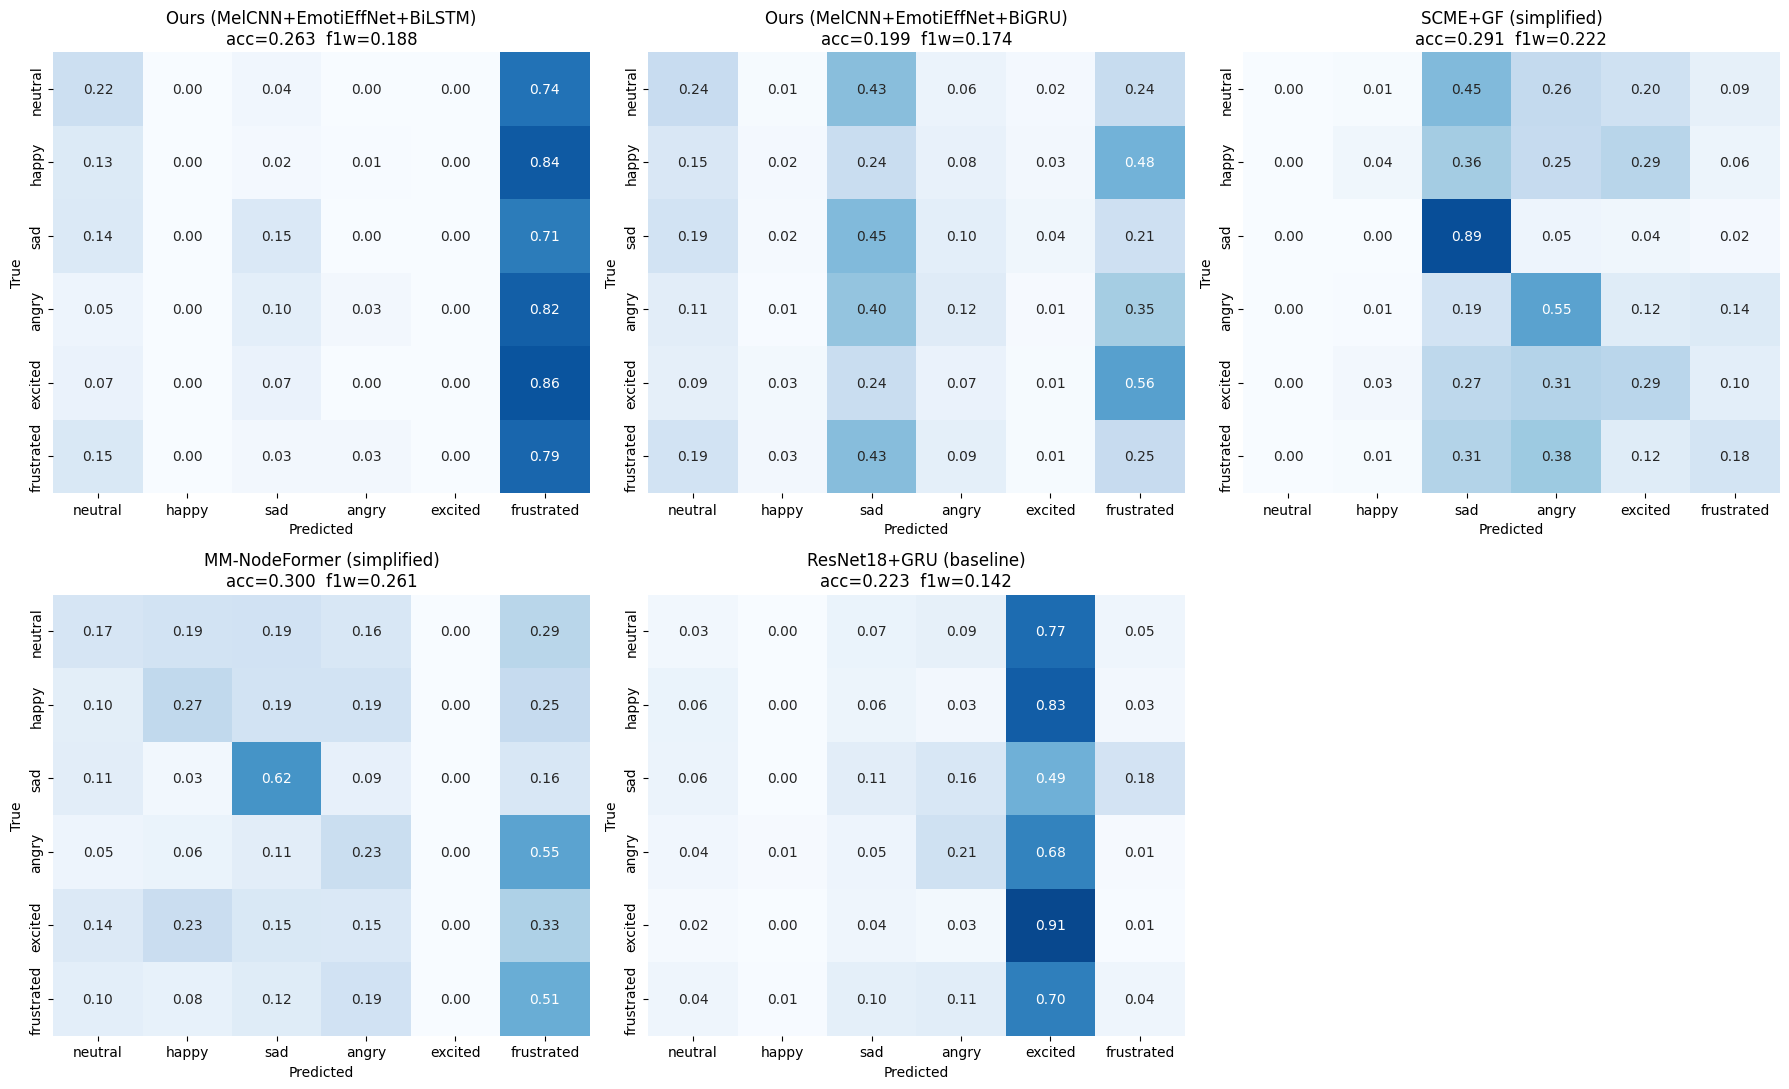

In [39]:
n = len(all_res)
cols = 3
rows_ = math.ceil(n / cols)
fig, axes = plt.subplots(rows_, cols, figsize=(6 * cols, 5.5 * rows_))
axes = np.atleast_2d(axes).ravel()
for ax, r in zip(axes, all_res):
    cm = confusion_matrix(r['y_true'], r['y_pred'], labels=np.arange(N_CLS))
    cmn = cm.astype(float) / cm.sum(1, keepdims=True).clip(min=1)
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABELS_6, yticklabels=LABELS_6,
                ax=ax, cbar=False, vmin=0, vmax=1)
    ax.set_title(f"{r['name']}\nacc={r['acc']:.3f}  f1w={r['f1w']:.3f}")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 12. Сводная таблица


In [40]:
summary = pd.DataFrame([{
    'Model':       r['name'],
    'Accuracy':    round(r['acc'], 4),
    'F1 weighted': round(r['f1w'], 4),
    'ms/sample':   round(r['ms_per_sample'], 2),
    'Size (MB)':   round(r['size_mb'], 2),
} for r in all_res]).sort_values('F1 weighted', ascending=False)
print(summary.to_string(index=False))
summary.to_csv(CKPT_OUT_DIR / 'benchmark_results.csv', index=False)

                           Model  Accuracy  F1 weighted  ms/sample  Size (MB)
      MM-NodeFormer (simplified)    0.2996       0.2605     622.01     381.12
            SCME+GF (simplified)    0.2910       0.2219     625.62     379.13
Ours (MelCNN+EmotiEffNet+BiLSTM)    0.2626       0.1876     537.48      29.11
 Ours (MelCNN+EmotiEffNet+BiGRU)    0.1991       0.1735     535.28      23.79
         ResNet18+GRU (baseline)    0.2232       0.1418     550.70      45.75


## 13. Визуальное сравнение моделей

Сводные графики по Accuracy, F1 weighted, инференсу (мс/сэмпл), размеру (MB) и trade-off F1↔скорость / F1↔размер.

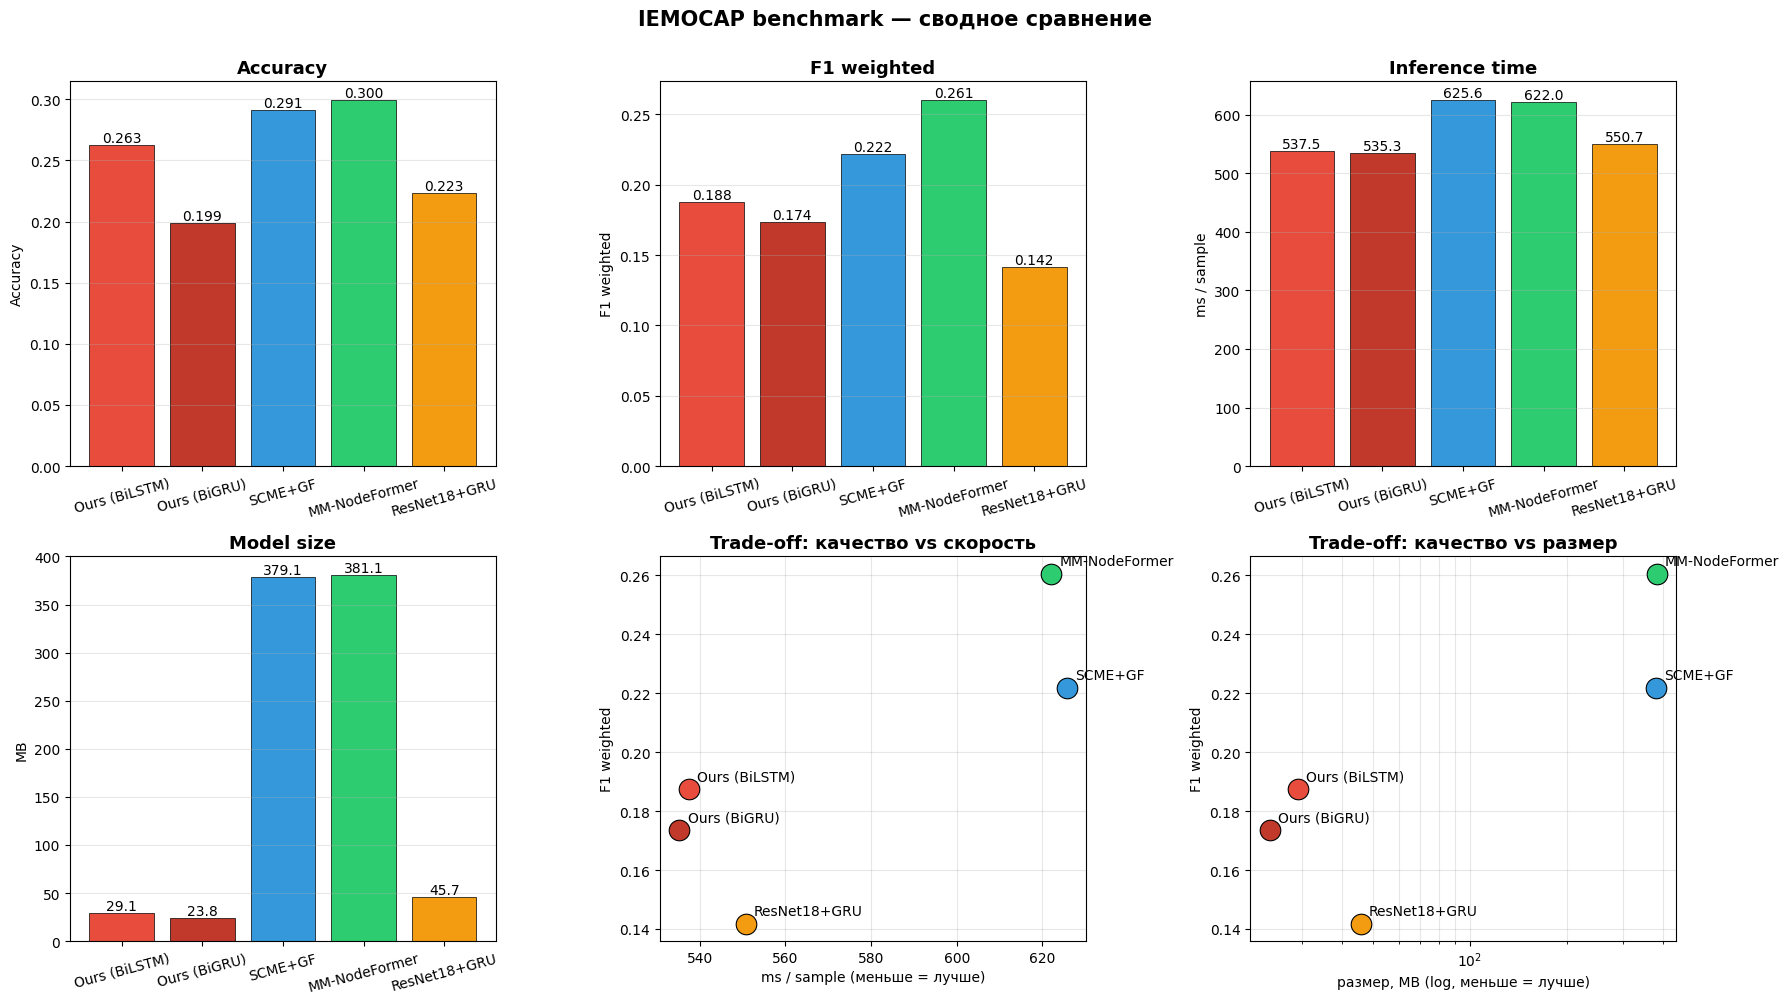

In [41]:
names  = [r['name']          for r in all_res]
accs   = [r['acc']           for r in all_res]
f1s    = [r['f1w']           for r in all_res]
times  = [r['ms_per_sample'] for r in all_res]
sizes  = [r['size_mb']       for r in all_res]

short = {
    'Ours (MelCNN+EmotiEffNet+BiLSTM)': 'Ours (BiLSTM)',
    'Ours (MelCNN+EmotiEffNet+BiGRU)':  'Ours (BiGRU)',
    'SCME+GF (simplified)':             'SCME+GF',
    'MM-NodeFormer (simplified)':       'MM-NodeFormer',
    'ResNet18+GRU (baseline)':          'ResNet18+GRU',
}
labels = [short.get(n, n) for n in names]
palette = ['#e74c3c', '#c0392b', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
colors = palette[:len(labels)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def bar(ax, vals, title, ylabel, fmt='{:.3f}'):
    bars = ax.bar(labels, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), fmt.format(v),
                ha='center', va='bottom', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

bar(axes[0, 0], accs,  'Accuracy',             'Accuracy')
bar(axes[0, 1], f1s,   'F1 weighted',          'F1 weighted')
bar(axes[0, 2], times, 'Inference time',       'ms / sample', fmt='{:.1f}')
bar(axes[1, 0], sizes, 'Model size',           'MB',          fmt='{:.1f}')

# trade-off: F1 vs speed (ниже-правее лучше по скорости, выше лучше по качеству)
ax = axes[1, 1]
for x, y, c, lab in zip(times, f1s, colors, labels):
    ax.scatter(x, y, s=220, c=c, edgecolor='black', linewidth=0.8, zorder=3)
    ax.annotate(lab, (x, y), xytext=(6, 6), textcoords='offset points', fontsize=10)
ax.set_xlabel('ms / sample (меньше = лучше)')
ax.set_ylabel('F1 weighted')
ax.set_title('Trade-off: качество vs скорость', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

ax = axes[1, 2]
for x, y, c, lab in zip(sizes, f1s, colors, labels):
    ax.scatter(x, y, s=220, c=c, edgecolor='black', linewidth=0.8, zorder=3)
    ax.annotate(lab, (x, y), xytext=(6, 6), textcoords='offset points', fontsize=10)
ax.set_xscale('log')
ax.set_xlabel('размер, MB (log, меньше = лучше)')
ax.set_ylabel('F1 weighted')
ax.set_title('Trade-off: качество vs размер', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, which='both')

plt.suptitle('IEMOCAP benchmark — сводное сравнение', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(CKPT_OUT_DIR / 'benchmark_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## Заметки
- IEMOCAP `.avi` содержит двоих актёров в одном кадре. Говорящий определяется чисто по видео: считаем frame-to-frame motion energy в области рта и в верхней части лица (лоб/глаза = baseline), вычитаем baseline и берём сторону с большей mouth-specific активностью. Без стерео-RMS, без per-session калибровки.
- Признаки кешируются на диск (`datasets/iemocap_features_cache_v3/*.pt`). Папка с суффиксом `_v3`, потому что после смены логики выбора стороны старые фичи (`_v2`) перестали быть валидны.
- SCME+GF и MM-NodeFormer реализованы упрощённо и служат как приближения к оригинальным статьям.
- Early stopping: best-checkpoint выбирается по F1w на val (Session 4); тест (Session 5) виден только для логов и финальной оценки.
